# Clustering: Comparativa de Métricas

Autores: Pablo Hernández Cámara (pablo.hernandez-camara@uv.es) y Pedro Ramón Ventura Gómez (pventura@march-am.com)



En este último notebook de algoritmos, someteremos a todos los métodos vistos (K-means, Jerárquico, DBSCAN y Mean Shift) a una comparativa objetiva utilizando el Silhouette Coefficient y otras métricas de validación interna.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm

plt.style.use('ggplot')

## Silhouette coefficient

El análisis de silueta se puede utilizar para estudiar la distancia de separación entre los clústeres obtenidos. El gráfico de silueta muestra una medida de la proximidad de cada punto de un clúster con respecto a los puntos de los clústeres vecinos y, por lo tanto, ofrece una forma de evaluar visualmente parámetros como el número de clústeres. Esta medida tiene un rango de [-1, 1].

Los coeficientes de silueta cercanos a +1 indican que la muestra está lejos de los clústeres vecinos. Un valor de 0 indica que la muestra se encuentra en el límite de decisión entre dos clústeres vecinos o muy cerca de él, y los valores negativos indican que esas muestras podrían haber sido asignadas al clúster equivocado.

In [ ]:
X, y = make_blobs(n_samples=500,n_features=2,centers=4,cluster_std=1,center_box=(-10.0, 10.0),shuffle=True,random_state=1)

**Ejercicio: Representa los datos y aplica k-means con k=4. Representa tambien los resultados.**

**Ejercicio: Calcula ahora el silhouette score para este resultado de clustering.**

**Ejercicio: Aplica ahora k-means con k={2,3,4,5,6}. En cada caso representa el resultado y calcula el valor del coeficiente de silueta.**

**Ejercicio: Ejecuta la función y comenta los resultados del gráfico de silueta.**

In [ ]:
for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.2, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),0,ith_cluster_silhouette_values,facecolor=color,edgecolor=color,alpha=0.7,)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k")

    centers = clusterer.cluster_centers_
    ax2.scatter(centers[:, 0],centers[:, 1],marker="o",c="white",alpha=1,s=200,edgecolor="k",)

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle("Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"% n_clusters,fontsize=14,fontweight="bold",)

plt.show()

Vamos a probar con otros datos más complicados y otros algoritmos.

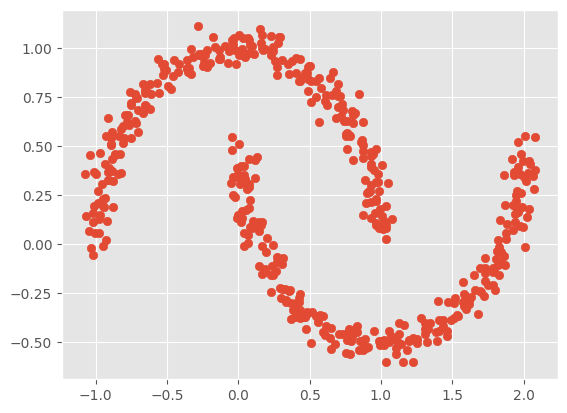

In [ ]:
X = make_moons(n_samples=500, noise=0.05, random_state=42)[0]

plt.scatter(X[:,0], X[:,1])
plt.show()

**Ejercicio: Aplica tanto k-means como DBSCAN. Antes de ponerte a programar, ¿cual va a salir mejor? ¿Por que?**

**Ejercicio: Calcula el silhouette average de cada metodo. Añadelo al titulo. ¿Que observas? ¿Por que pasa esto?**

El problema no es que el clustering de DBSCAN esté mal, sino que el Silhouette Score tiene un sesgo hacia la convexidad (formas circulares o esféricas) ya que el coeficiente de silueta mide la distancia media de un punto a los de su propio grupo frente a la distancia media al grupo vecino más cercano.

Por eso es importante entender lo que estamos haciendo y no solo calcular valores y ya.

Vamos a calcular tmabién otras métricas, por ejemplo:

Calinski-Harabasz (Valor ideal: Alto) - Ratio de varianzas.

Davies-Bouldin (Valor ideal: Bajo) - Similitud entre clusters.

In [ ]:
def eval_clustering(nombre, labels, data):
    # DBSCAN y otros pueden devolver -1 (ruido), lo ignoramos para las métricas
    mask = labels != -1
    if len(np.unique(labels[mask])) < 2:
        return {"Algoritmo": nombre, "Silhouette": np.nan, "C-H": np.nan, "D-B": np.nan}

    s_score = silhouette_score(data, labels)
    ch_score = calinski_harabasz_score(data, labels)
    db_score = davies_bouldin_score(data, labels)

    return {"Algoritmo": nombre,
            "Silhouette": s_score,
            "C-H": ch_score,
            "D-B": db_score,
            "Clusters": len(np.unique(labels[mask]))}

## Evaluaciones en distintos datasets

In [ ]:
n_samples = 500
datasets = [("Blobs", make_blobs(n_samples=n_samples, centers=2, cluster_std=0.6, random_state=42)[0]),
            ("Moons", make_moons(n_samples=n_samples, noise=0.05, random_state=42)[0]),
            ("Circles", make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=42)[0])]

**Ejercicio: Representa los 3 datasets.**

In [ ]:
modelos = [("K-Means", KMeans(n_clusters=2, n_init=10)),
           ("Agglomerative", AgglomerativeClustering(n_clusters=2)),
           ("DBSCAN", DBSCAN(eps=0.2, min_samples=5)),
           ("Mean Shift", MeanShift(bandwidth=0.4))]

**Ejercicio: Evalua cada modelo en cada uno de los datasets. Calcula las distintas metricas.**